# Convolutions


### Animations

Blue (bottom) is the input, gray is the sliding kernel, green (top) is the output. Dashed cells are zero padding.

<table>
<tr>
  <td align="center" style="padding:8px">
    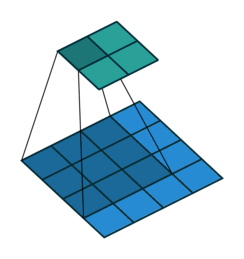<br>
    <sub>padding = 0, stride = 1</sub>
  </td>
  <td align="center" style="padding:8px">
    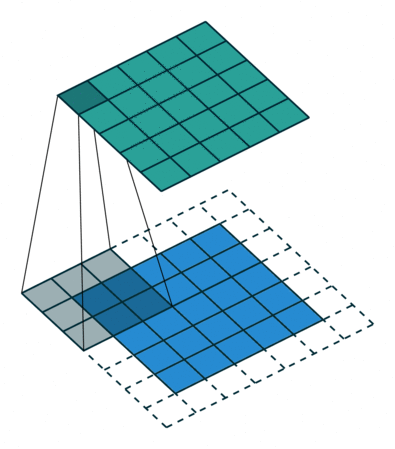<br>
    <sub>padding = 1, stride = 1</sub>
  </td>
</tr>
<tr>
  <td align="center" style="padding:8px">
    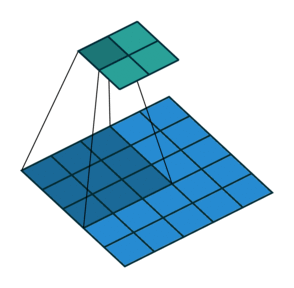<br>
    <sub>padding = 0, stride = 2</sub>
  </td>
  <td align="center" style="padding:8px">
    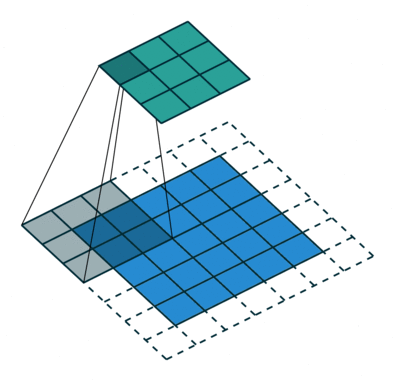<br>
    <sub>padding = 1, stride = 2</sub>
  </td>
</tr>
</table>

<sub>Animations from V. Dumoulin & F. Visin, <a href="https://github.com/vdumoulin/conv_arithmetic">"A guide to convolution arithmetic for deep learning"</a> (2016).</sub>


## Definition: Infinite 2D Convolution

Input  
* $X \in \mathbb{R}^{C_1\times \mathbb{Z}^2}.$  

Weights  
* kernel $W \in \mathbb{R}^{C_2\times C_1 \times h \times w}$  
* bias $b \in \mathbb{R}^{C_2}$  

Hyperparameters  
* stride $s=(s_1,s_2)$    

Output  
* $\operatorname{InfConv2d}_{W,b}(X) = O \in \mathbb{R}^{C_2\times \mathbb{Z}^2}$, where  

$$
\begin{align*}
O_{i,j,k} &= b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
x_{l,\,(j-1)\cdot s_1 + m,\, (k-1)\cdot s_2 + n}\,
\omega_{i,l,m,n}.
\end{align*}
$$


### Property: $\operatorname{InfConv2d}_{W,0}$ is linear and $\operatorname{InfConv2d}_{W,b}$ is affine

Proof:
$$
\begin{align*}
\operatorname{InfConv2d}_{W,0}(\alpha X+\beta Y) &=\sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w}(\alpha x_{l,(j-1)s_1+m,(k-1)s_2+n}+\beta y_{l,(j-1)s_1+m,(k-1)s_2+n})\cdot \omega_{i,l,m,n},\\
&=\sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w}(\alpha x_{l,(j-1)s_1+m,(k-1)s_2+n}\cdot \omega_{i,l,m,n}+\beta y_{l,(j-1)s_1+m,(k-1)s_2+n}\cdot \omega_{i,l,m,n}),\\
&=\alpha\sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w} x_{l,(j-1)s_1+m,(k-1)s_2+n}\cdot \omega_{i,l,m,n}+\beta \sum_{l=1}^{C_1}\sum_{m=1}^{h}\sum_{n=1}^{w}y_{l,(j-1)s_1+m,(k-1)s_2+n}\cdot \omega_{i,l,m,n},\\
&=\alpha \operatorname{InfConv2d}_{W,0}(X)+\beta \operatorname{InfConv2d}_{W,0}(Y).
\end{align*}
$$

#### Definition: Positional translation
Given $\delta\in \mathbb{Z}^2$ and a channel dimension $C\in\mathbb{N}$. We define the "positional" translation of $\delta$ units as
$$
\begin{align*}
T^{C}_{\delta}:  \mathbb{R}^{C\times \mathbb{Z}^2}&\longmapsto \mathbb{R}^{C\times \mathbb{Z}^2} ,&\quad \text{where} \quad   Y_{i,j,k}&=X_{i,j+\delta_1,k+\delta_2}.\\
 T^{C}_{\delta} (X) &= Y & 
\end{align*}
$$

### Property: $\operatorname{InfConv2d}_{W,b}$ is translation-equivariant up to stride

If $\operatorname{InfConv2d}_{W,b}: \mathbb{R}^{C_1\times \mathbb{Z}^2} \longmapsto \mathbb{R}^{C_2\times \mathbb{Z}^2}$ with stride $s$, then
$$\operatorname{InfConv2d}_{W,b}\circ \ T^{C_1}_{s*\delta} = T^{C_2}_{\delta}\circ \operatorname{InfConv2d}_{W,b}, \quad \forall\delta \in \mathbb{Z}^2.$$

In particular, for stride $s=(1,1)$, **full translation equivariance** holds.


Proof: Let $(i,j,k)\in C\times\mathbb{Z}^2$ 
$$
\begin{align*}
\operatorname{InfConv2d}_{W,b}\circ \ T^{C_1}_{s*\delta}(X)_{i,j,k}&=\operatorname{InfConv2d}_{W,b}\left( T^{C_1}_{s*\delta}(X)\right)_{i,j,k}\omega_{i,l,m,n},\\
&=b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
T^{C_1}_{s*\delta}(X)_{l,\,(j-1)\cdot s_1 + m,\, (k-1)\cdot s_2 + n}\omega_{i,l,m,n},\\
&=b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
x_{l,\,(j-1)\cdot s_1 + m+s_1\delta_1,\, (k-1)\cdot s_2 + n+s_2\delta_2}\omega_{i,l,m,n},\\
&=b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
x_{l,\,(j+\delta_1-1)\cdot s_1 + m,\, (k+\delta_2-1)\cdot s_2 + n}\omega_{i,l,m,n},\\
&=\operatorname{InfConv2d}_{W,b}(X)_{i,j+\delta_1,k+\delta_2},\\
&=T^{C_2}_{\delta}(\operatorname{InfConv2d}_{W,b}(X))_{i,j,k},\\
&=T^{C_2}_{\delta}\circ\operatorname{InfConv2d}_{W,b}(X)_{i,j,k}.
\end{align*}
$$

Then $\operatorname{Conv2d}_{W,b}\circ \ T^{C_1}_{s*\delta} = T^{C_2}_{\delta}\circ \operatorname{Conv2d}_{W,b}$ and we conclude that $\operatorname{InfConv2d}_{W,b}$ is translation equivariance


#### Definition: Padding operation

$$
\begin{align*}
\operatorname{Pad}^{(p_1,p_2)}:\bigcup_{H,W \in \mathbb{N}}\mathbb{R}^{C\times H\times W}&\longmapsto \mathbb{R}^{C\times \mathbb{Z}^2}, \\
\operatorname{Pad}^{(p_1,p_2)} (X) &= Y
\end{align*}
$$
where
$$
Y_{i,j,k}=\begin{cases} X_{i,j-p_1,k-p_2}, & p_1< j\leq H+p_1, p_2 < k\leq W+p_2, \\
0,& \text{otherwise} \\
\end{cases}\\
$$

### Property: $\operatorname{Pad}^{(p_1,p_2)}\big|_{\mathbb{R}^{C\times H\times W}}$ is linear 

Proof: Let $\alpha,\beta \in \mathbb{R}$, $X,Y \in \mathbb{R}^{C\times H\times W}$, and $(i,j,k)\in C\times \mathbb{Z}^2$ then 
$$
\begin{align*}
\operatorname{Pad}^{(p_1,p_2)} (\alpha X+ \beta Y)_{i,j,k}&=\begin{cases} \alpha X_{i,j-p_1,k-p_2}+\beta Y_{i,j-p_1,k-p_2}, & p_1< j\leq H+p_1, p_2 < k\leq W+p_2 \\
0,& \text{otherwise} \\
\end{cases}\\
&=\alpha\begin{cases} X_{i,j-p_1,k-p_2}, & p_1< j\leq H+p_1, p_2 < k\leq W+p_2 \\
0,& \text{otherwise} \\
\end{cases}\\
&+\beta \begin{cases}Y_{i,j-p_1,k-p_2}, & p_1< j\leq H+p_1, p_2 < k\leq W+p_2 \\
0,& \text{otherwise} \\
\end{cases}\\
&=\alpha\operatorname{Pad}^{(p_1,p_2)} (X)_{i,j,k}+\beta \operatorname{Pad}^{(p_1,p_2)} (Y)_{i,j,k},\\
&=(\alpha\operatorname{Pad}^{(p_1,p_2)} (X)+\beta \operatorname{Pad}^{(p_1,p_2)} (Y))_{i,j,k},\\
\end{align*}
$$
 
 Then $\operatorname{Pad}^{(p_1,p_2)} (\alpha X+ \beta Y) = \alpha\operatorname{Pad}^{(p_1,p_2)} (X)+\beta \operatorname{Pad}^{(p_1,p_2)} (Y)$ and we conclude that $\operatorname{Pad}^{(p_1,p_2)}\big|_{\mathbb{R}^{C\times H\times W}}$ is linear

#### Definition: Crop operation

$$
\begin{align*}
\operatorname{Crop}^{(*,H,W)}\!: \ \ \mathbb{R}^{C\times\mathbb{Z}^2}&\longmapsto \mathbb{R}^{C\times H\times W} ,\\
\operatorname{Crop}^{(*,H,W)} (X) &= Y
\end{align*}
$$

where
$$
Y_{i,j,k}=X_{i,j,k}, \quad  1\leq j\leq H, 1\leq k\leq W.\\
$$

### Property: $\operatorname{Crop}^{(*,H,W)}$ is linear 

Proof: Let $\alpha,\beta \in \mathbb{R}$, $X,Y \in \mathbb{R}^{C\times H\times W}$, and $(i,j,k)\in C\times H \times W$ then 
$$
\begin{align*}
\operatorname{Crop}^{(*,H,W)}(\alpha X+ \beta Y)_{i,j,k}&=(\alpha X+\beta Y)_{i,j,k}, \\
&=\alpha X_{i,j,k}+\beta Y_{i,j,k}, \\
&=\alpha\operatorname{Crop}^{(*,H,W)} (X)_{i,j,k}+\beta \operatorname{Crop}^{(*,H,W)} (Y)_{i,j,k},\\
&=(\alpha\operatorname{Crop}^{(*,H,W)} (X)+\beta \operatorname{Crop}^{(*,H,W)} (Y))_{i,j,k},\\
\end{align*}
$$
 
 Then $\operatorname{Crop}^{(*,H,W)}(\alpha X+ \beta Y) = \alpha\operatorname{Crop}^{(*,H,W)}(X)+\beta \operatorname{Crop}^{(*,H,W)} (Y)$ and we conclude that $\operatorname{Crop}^{(*,H,W)}$ is linear

## Definition: Finite 2D Convolution (with padding)

In practice we don't have "inifinite" tensors, we only can pass finite dimensional inputs to convolution, so we need a finite convolution definition

Input  
* $X \in \mathbb{R}^{C_1\times H \times W}, \quad \text{for } H,W\in \mathbb{N}.$  

Weights  
* kernel $W \in \mathbb{R}^{C_2\times C_1 \times h \times w}$  
* bias $b \in \mathbb{R}^{C_2}$  

Hyperparameters  
* stride $s=(s_1,s_2)$  
* padding $p=(p_1,p_2)$  

Output  
* $\operatorname{Conv2d}_{W,b} = \operatorname{Crop}^{(*,H',W')}\circ\operatorname{InfConv2d}_{W,b}\circ\operatorname{Pad}^{(p_1,p_2)}$ 

where  
$$
\begin{align*}
H' &= \left\lfloor \frac{H + 2p_1 - h}{s_1} \right\rfloor + 1, \\
W' &= \left\lfloor \frac{W + 2p_2 - w}{s_2} \right\rfloor + 1.
\end{align*}
$$

Notice that the indexes position $(j,k): j<1,j>H+2p_1, k<1$, or $k>W+2p_2$ are created by the padding and then deleted by the Crop. So we can simplified the formulation as follow   

Output  
* $\operatorname{Conv2d}_{W,b}(X) = O \in \mathbb{R}^{C_2 \times H' \times W'}$, where  

$$
\begin{align*}
O_{i,j,k} &= b_{i} + \sum_{l=1}^{C_1} \sum_{m=1}^{h} \sum_{n=1}^{w}
\tilde{x}_{l,\,(j-1)\cdot s_1 + m,\, (k-1)\cdot s_2 + n}\,
\omega_{i,l,m,n}.
\end{align*}
$$

where $\tilde{X} \in \mathbb{R}^{C_1 \times (H + 2p_1) \times (W + 2p_2)}$ is $X$ padded with $p_1$ zeros on the top and bottom and $p_2$ zeros on the left and right for each channel: 
$$
\begin{align*}
\operatorname{Pad}(X)&=\tilde{X},\\
\tilde{X}_{i,:,:} & = \begin{pmatrix} 
0_{p_1\!\times p_2} & 0_{p_1\!\times W} & 0_{p_1\!\times p_2},\\
0_{H \!\times p_2} & X_{i,:,:} & 0_{H \!\times p_2},\\
0_{p_1\!\times p_2} & 0_{p_1\!\times W} & 0_{p_1\!\times p_2},\\
\end{pmatrix}, \quad i=1,2,\dots,C_1.
\end{align*}
$$

**Note:** The same convolution function can be applied to inputs of different spatial shapes. The model parameters are not tied to specific coordinates. In this sense, $\operatorname{Conv2d}_{W,b}$ is **position-agnostic**.

### Property: $\operatorname{Conv2d}_{W,0}\big|_{\mathbb{R}^{C\times H\times W}}$ is linear and $\operatorname{Conv2d}_{W,b}\big|_{\mathbb{R}^{C\times H\times W}}$ is affine 

Proof: Notice that 
$$
\begin{align*}
\operatorname{Conv2d}_{W,b}\big|_{\mathbb{R}^{C\times H\times W}}=\operatorname{Crop}^{(*,H',W')}\circ\operatorname{InfConv2d}_{W,b}\circ(\operatorname{Pad}^{(p_1,p_2)}\big|_{\mathbb{R}^{C\times H\times W}})
\end{align*}
$$
Then the results comes directly from the previous results: 
* $\operatorname{Crop}^{(*,H',W')}$ is linear, 
* $\operatorname{Pad}^{(p_1,p_2)}\big|_{\mathbb{R}^{C\times H\times W}}$ is linear  
* $\operatorname{InfConv2d}_{W,0}$ is linear and $\operatorname{InfConv2d}_{W,b}$ is affine

## Matrix representation of $\operatorname{Conv2d}$ (valid case: $p=0$, $s=1$)

Because $\operatorname{Conv2d}_{W,b}\big|_{\mathbb{R}^{C_1\times H\times W}}$ is affine, it can be written as a single matrix–vector product. Take the **valid** convolution ($p=(0,0)$, $s=(1,1)$), so $H'=H-h+1$, $W'=W-w+1$, and flatten the tensors to vectors of length
$$
d_x = C_1 H W, \qquad d_y = C_2 H' W'.
$$
Then
$$
\operatorname{conv}(x)=\mathcal{W}\,x+\mathbf{b},\qquad \mathcal{W}\in\mathbb{R}^{d_y\times d_x}.
$$

Stacking the output by spatial position $(j,k)$ (output channel $i$ innermost),
$$
\mathcal{W}=\begin{pmatrix}\mathcal{W}_{1,1}\\ \mathcal{W}_{1,2}\\ \vdots\\ \mathcal{W}_{H',W'}\end{pmatrix}_{d_y\times d_x},
\qquad
\mathbf{b}=\begin{pmatrix}b_{1,1}\\ b_{1,2}\\ \vdots\\ b_{H',W'}\end{pmatrix}_{d_y},
$$
where each block $\mathcal{W}_{j,k}\in\mathbb{R}^{C_2\times d_x}$ and $b_{j,k}\in\mathbb{R}^{C_2}$ produce output column $(j,k)$:
$$
\operatorname{conv}_{j,k}(x)=\mathcal{W}_{j,k}\,x+b_{j,k},
\qquad
\mathcal{W}_{j,k}=\big(\;\mathcal{W}_{j,k,1}\,\big|\,\mathcal{W}_{j,k,2}\,\big|\,\cdots\,\big|\,\mathcal{W}_{j,k,C_1}\;\big)_{C_2\times C_1 HW}.
$$

Per input channel $l$, the block $\mathcal{W}_{j,k,l}\in\mathbb{R}^{C_2\times HW}$ places the kernel over the $h\times w$ window anchored at $(j,k)$:
$$
\mathcal{W}_{j,k,l}=\big(\;O_{C_2\times (j-1)W}\,\big|\,B_{l,1,k}\,\big|\,B_{l,2,k}\,\big|\,\cdots\,\big|\,B_{l,h,k}\,\big|\,O_{C_2\times (H-h-j+1)W}\;\big)_{C_2\times HW},
$$
where the block index runs over the **kernel row** $m=1,\dots,h$ (the offset into the window, *not* the absolute input row), and each $B_{l,m,k}\in\mathbb{R}^{C_2\times W}$ is
$$
B_{l,m,k}=\begin{pmatrix}
\underbrace{0\;\cdots\;0}_{k-1} & \omega_{1,l,m,1} & \cdots & \omega_{1,l,m,w} & \underbrace{0\;\cdots\;0}_{W-w-k+1}\\
\underbrace{0\;\cdots\;0}_{k-1} & \omega_{2,l,m,1} & \cdots & \omega_{2,l,m,w} & \underbrace{0\;\cdots\;0}_{W-w-k+1}\\
\vdots & \vdots & \ddots & \vdots & \vdots\\
\underbrace{0\;\cdots\;0}_{k-1} & \omega_{C_2,l,m,1} & \cdots & \omega_{C_2,l,m,w} & \underbrace{0\;\cdots\;0}_{W-w-k+1}
\end{pmatrix}_{C_2\times W},
$$
with $O_{n\times m}$ the $n\times m$ zero matrix. The vectors are flattened row-major,
$$
x=\big(x_{1,1,1},\,x_{1,1,2},\,\dots,\,x_{1,1,W},\,x_{1,2,1},\,\dots,\,x_{C_1,H,W}\big)^{\!\top},
\qquad
b_{j,k}=\big(b_{1,j,k},\,b_{2,j,k},\,\dots,\,b_{C_2,j,k}\big)^{\!\top}.
$$

**Why it is correct.** Block $B_{l,m,k}$ sits in the column band of input row $r=(j-1)+m$ (the front zeros cover rows $1,\dots,j-1$), and inside it the $k-1$ leading zeros shift the kernel to input column $c=(k-1)+n$. Hence
$$
\big[\mathcal{W}_{j,k,l}\,\operatorname{vec}(x_l)\big]_i=\sum_{m=1}^{h}\sum_{n=1}^{w}\omega_{i,l,m,n}\,x_{l,\,(j-1)+m,\,(k-1)+n},
$$
and summing over $l$ and adding $b_{i,j,k}$ reproduces exactly $O_{i,j,k}$ from the finite convolution definition. The band widths add up to $(j-1)W+hW+(H-h-j+1)W=HW$, so each block indeed has $HW$ columns.


In [1]:
# Verify the block-Toeplitz matrix reproduces Conv2d (valid: p=0, s=1)
import torch

import models.deep_learning.architectures.convolution.conv2d as mynn

C1, C2, H, W, h, w = 2, 3, 5, 4, 3, 2

torch.manual_seed(0)
conv = mynn.Conv2d(C1, C2, (h, w), stride=1, padding=0)
Wmat, bvec = conv.to_matrix(H, W)  # block-Toeplitz matrix + bias vector

x = torch.randn(1, C1, H, W)
y_conv = conv(x)[0]
Hp, Wp = y_conv.shape[-2:]
# W stacks blocks (j,k)-outer, channel-inner -> (Hp, Wp, C2); permute to (C2, Hp, Wp)
y_mat = (Wmat @ x.reshape(-1) + bvec).reshape(Hp, Wp, C2).permute(2, 0, 1)
print("max |W x + b - conv(x)| =", (y_mat - y_conv).abs().max().item())
print("allclose:", torch.allclose(y_mat, y_conv, atol=1e-5))


max |W x + b - conv(x)| = 5.960464477539063e-08
allclose: True


### General padding $p$ and stride $s$

The restriction $p=0,\,s=1$ was only to keep the indices clean — every factor of $\operatorname{Conv2d}=\operatorname{Crop}\circ\operatorname{InfConv2d}\circ\operatorname{Pad}$ is linear, so a matrix always exists. Build it on the **padded** input $\tilde x=\operatorname{Pad}^{(p_1,p_2)}(x)\in\mathbb{R}^{C_1\times\tilde H\times\tilde W}$ with $\tilde H=H+2p_1$, $\tilde W=W+2p_2$, and output sizes
$$
H'=\left\lfloor\tfrac{\tilde H-h}{s_1}\right\rfloor+1,\qquad
W'=\left\lfloor\tfrac{\tilde W-w}{s_2}\right\rfloor+1.
$$

The block form is identical to the valid case after replacing the anchors $(j-1)\!\mapsto\!(j-1)s_1$, $(k-1)\!\mapsto\!(k-1)s_2$ and $H,W\!\mapsto\!\tilde H,\tilde W$:
$$
\tilde{\mathcal W}_{j,k,l}=\big(\;O_{C_2\times (j-1)s_1\tilde W}\,\big|\,B_{l,1,k}\,\big|\,\cdots\,\big|\,B_{l,h,k}\,\big|\,O_{C_2\times (\tilde H-h-(j-1)s_1)\tilde W}\;\big)_{C_2\times \tilde H\tilde W},
$$
$$
B_{l,m,k}=\Big(\;\underbrace{0\cdots0}_{(k-1)s_2}\;\big|\;\omega_{\cdot,l,m,1}\;\cdots\;\omega_{\cdot,l,m,w}\;\big|\;\underbrace{0\cdots0}_{\tilde W-w-(k-1)s_2}\;\Big)_{C_2\times \tilde W}.
$$
So **stride** just makes the nonzero bands *step by $s$* (front zeros $(j-1)s_1\tilde W$, in-row zeros $(k-1)s_2$) and subsamples the output rows.

**Padding** is folded back onto the original $x$ by composing with the padding matrix. $\operatorname{Pad}^{(p_1,p_2)}$ is a $0/1$ selection matrix $S_{\mathrm{pad}}\in\mathbb{R}^{C_1\tilde H\tilde W\times C_1 HW}$, hence
$$
\mathcal W=\tilde{\mathcal W}\,S_{\mathrm{pad}}\in\mathbb{R}^{d_y\times d_x},\qquad \operatorname{conv}(x)=\mathcal W x+\mathbf b .
$$
Concretely, $\mathcal W$ equals $\tilde{\mathcal W}$ with the columns of the padded (out-of-range) positions **dropped**: a kernel entry $\omega_{i,l,m,n}$ contributes to $x_{l,r,c}$ only when the padded coordinate $\big((j-1)s_1+m,\ (k-1)s_2+n\big)$ maps back inside the image, i.e. $1\le r=(j-1)s_1+m-p_1\le H$ and $1\le c=(k-1)s_2+n-p_2\le W$; otherwise it multiplies a zero and is omitted.


# Verify the general block-Toeplitz matrix reproduces Conv2d for any (s, p)

In [2]:
# Verify the general block-Toeplitz matrix reproduces Conv2d for any (s, p)
import torch

import models.deep_learning.architectures.convolution.conv2d as mynn

C1, C2, H, W, h, w = 2, 3, 7, 6, 3, 3
for s, p in [((1, 1), (0, 0)), ((2, 2), (1, 1)), ((2, 1), (1, 2)), ((3, 2), (2, 1))]:
    torch.manual_seed(0)
    conv = mynn.Conv2d(C1, C2, (h, w), stride=s, padding=p)
    Wmat, bvec = conv.to_matrix(H, W)

    x = torch.randn(1, C1, H, W)
    y_conv = conv(x)[0]
    Hp, Wp = y_conv.shape[-2:]
    y_mat = (Wmat @ x.reshape(-1) + bvec).reshape(Hp, Wp, C2).permute(2, 0, 1)
    ok = torch.allclose(y_mat, y_conv, atol=1e-5)
    print(f"s={s} p={p}: out={tuple(y_conv.shape)} allclose={ok}")


s=(1, 1) p=(0, 0): out=(3, 5, 4) allclose=True
s=(2, 2) p=(1, 1): out=(3, 4, 3) allclose=True
s=(2, 1) p=(1, 2): out=(3, 4, 8) allclose=True
s=(3, 2) p=(2, 1): out=(3, 3, 3) allclose=True


## Code: $\operatorname{Conv2d}_{W,b}$

$\operatorname{InfConv2d}_{W,b}$ requires infinite dimentional inputs so it has only theoretical meaning

In [3]:
import torch
import torch.nn as nn

import models.deep_learning.architectures.convolution.conv2d as mynn


## Testing

In [4]:
in_channels = 3
out_channels = 2
kernel_size = 3
stride = 1
padding = 1

batch_size = 2

In [5]:
torch.manual_seed(0)
nn_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
torch.manual_seed(0)
conv = mynn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)

## Weights

In [4]:
for name, param in nn_conv.named_parameters():
    print(name, param.shape)
for name, param in nn_conv.named_parameters():
    print(name, param.shape)

weight torch.Size([2, 3, 3, 3])
bias torch.Size([2])
weight torch.Size([2, 3, 3, 3])
bias torch.Size([2])


### Output

In [10]:
x = torch.randn(batch_size, in_channels, 5, 5)
nn_out = nn_conv(x)
out = conv(x)
print(f"{nn_out.shape=}")
print(f"{out.shape=}")
ok = torch.allclose(nn_out, out, atol=1e-5)
print(f"allclose={ok}")

nn_out.shape=torch.Size([2, 2, 5, 5])
out.shape=torch.Size([2, 2, 5, 5])
allclose=True
